<a href="https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_1_4_SVD_Low_Rank_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ehuangasu/MAT422/blob/main/MAT422_Section_1_4_SVD_Low_Rank_PCA.ipynb)

# MAT 422 - Section 1.4: SVD, Low-Rank Approximation, and PCA

**Topics:** singular value decomposition, low-rank matrix approximations, principal component analysis

In [19]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Singular Value Decomposition

Singular value decomposition factors a matrix A into A = U Sigma V^T. The columns of U and V are orthonormal directions, and the singular values in Sigma measure how much each direction contributes to the matrix.

(NEW)

One can think of U and V^T as rotation matrices, and Sigma as a scaling matrix. V^T turns a vector into a new basis with the principal component axes. Sigma then stretches each dimension by a specific amount, and U is another rotation matrix back to the output of A.

In [20]:
A = np.array([
    [3, 2, 2],
    [2, 3, -2],
    [1, 1, 0],
    [0, 2, 1],
], dtype=float)

U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sigma = np.diag(s)
A_reconstructed = U @ Sigma @ Vt

print("A =")
print(A)
print("\nSingular values =", s)
print("\nU shape, Sigma shape, Vt shape =", U.shape, Sigma.shape, Vt.shape)
print("\nU.T @ U =")
print(U.T @ U)
print("\nVt @ Vt.T =")
print(Vt @ Vt.T)
print("\nReconstruction error ||A - U Sigma Vt||_F =", np.linalg.norm(A - A_reconstructed, ord="fro"))
print("Reconstruction is accurate?", np.allclose(A, A_reconstructed))

A =
[[ 3.  2.  2.]
 [ 2.  3. -2.]
 [ 1.  1.  0.]
 [ 0.  2.  1.]]

Singular values = [5.4071 3.0452 1.5779]

U shape, Sigma shape, Vt shape = (4, 3) (3, 3) (3, 3)

U.T @ U =
[[ 1.  0. -0.]
 [ 0.  1. -0.]
 [-0. -0.  1.]]

Vt @ Vt.T =
[[ 1. -0. -0.]
 [-0.  1.  0.]
 [-0.  0.  1.]]

Reconstruction error ||A - U Sigma Vt||_F = 5.375046761694035e-15
Reconstruction is accurate? True


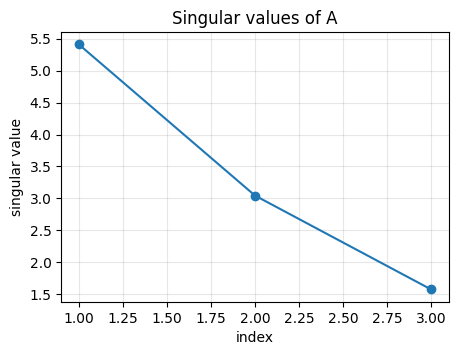

In [21]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(s) + 1), s, marker="o")
plt.xlabel("index")
plt.ylabel("singular value")
plt.title("Singular values of A")
plt.grid(True, alpha=0.3)
plt.show()

Large singular values indicate directions that carry more structure. Smaller singular values contribute less, which is why SVD is useful for approximation and compression.

Note that all the singular values are over 1, so the matrix stretches in all its principal axes.

## 1.4.2 Low-Rank Matrix Approximations

A rank-k approximation keeps only the first k singular values and singular vectors. This gives a simpler matrix A_k that captures the strongest patterns in A.

In [22]:
def rank_k_approximation(U, s, Vt, k):
    return U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]

errors = []
for k in range(1, len(s) + 1):
    A_k = rank_k_approximation(U, s, Vt, k)
    error = np.linalg.norm(A - A_k, ord="fro")
    errors.append(error)
    print(f"Rank-{k} approximation:")
    print(A_k)
    print("Frobenius error =", error)
    print("matrix rank =", np.linalg.matrix_rank(A_k))
    print()

Rank-1 approximation:
[[2.3471 2.7154 0.232 ]
 [2.2456 2.5979 0.2219]
 [0.9185 1.0627 0.0908]
 [1.0274 1.1886 0.1015]]
Frobenius error = 3.4297069364073947
matrix rank = 1

Rank-2 approximation:
[[ 2.6053  2.3309  2.1213]
 [ 1.9444  3.0466 -1.9829]
 [ 0.9099  1.0755  0.0277]
 [ 1.1039  1.0748  0.6609]]
Frobenius error = 1.577861346829626
matrix rank = 2

Rank-3 approximation:
[[ 3.  2.  2.]
 [ 2.  3. -2.]
 [ 1.  1.  0.]
 [ 0.  2.  1.]]
Frobenius error = 5.375046761694035e-15
matrix rank = 3



(NEW)

The rank 1 approximation only keeps the highest singular value principal axis, the rank 2 approx also keeps the 2nd highest, etc.

The plot below shows the Frobenius error for the first 3 low rank approximations. Using SVD and taking the highest k singular values as an approximation minimizes Frobenius error across all matrices of rank k.

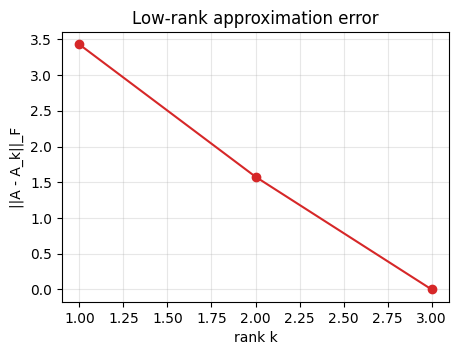

In [23]:
plt.figure(figsize=(5, 3.5))
plt.plot(np.arange(1, len(errors) + 1), errors, marker="o", color="tab:red")
plt.xlabel("rank k")
plt.ylabel("||A - A_k||_F")
plt.title("Low-rank approximation error")
plt.grid(True, alpha=0.3)
plt.show()

The approximation error decreases as k increases. When k reaches the full rank, the approximation becomes the original matrix up to numerical roundoff.

## 1.4.3 Principal Component Analysis

Principal component analysis finds directions of maximum variation in centered data. PCA can be computed using SVD: after centering the data matrix X, the rows of V^T give principal component directions.

In [24]:
X = np.array([
    [2.5, 2.4],
    [0.5, 0.7],
    [2.2, 2.9],
    [1.9, 2.2],
    [3.1, 3.0],
    [2.3, 2.7],
    [2.0, 1.6],
    [1.0, 1.1],
    [1.5, 1.6],
    [1.1, 0.9],
], dtype=float)

mean = X.mean(axis=0)
X_centered = X - mean
U_pca, s_pca, Vt_pca = np.linalg.svd(X_centered, full_matrices=False)
scores = X_centered @ Vt_pca.T
explained_variance = (s_pca**2) / (len(X) - 1)
explained_ratio = explained_variance / explained_variance.sum()

print("feature means =", mean)
print("principal directions as rows of Vt =")
print(Vt_pca)
print("singular values =", s_pca)
print("explained variance =", explained_variance)
print("explained variance ratio =", explained_ratio)
print("first three PCA scores =")
print(scores[:3])

feature means = [1.81 1.91]
principal directions as rows of Vt =
[[-0.6779 -0.7352]
 [ 0.7352 -0.6779]]
singular values = [3.3994 0.6646]
explained variance = [1.284  0.0491]
explained variance ratio = [0.9632 0.0368]
first three PCA scores =
[[-0.828   0.1751]
 [ 1.7776 -0.1429]
 [-0.9922 -0.3844]]


(NEW)

The first singular value is high (3.39), much higher than the second (0.66), which predicts that that principal axis explains more variance. We can see that that axis explains 96% of the variance of the two axes. We can check this prediction with the plot below:

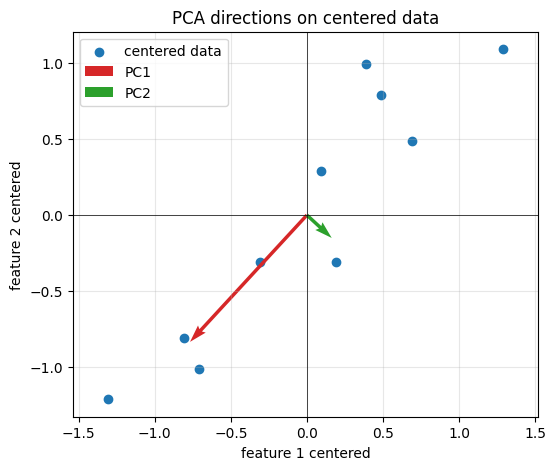

In [25]:
origin = np.zeros(2)
pc1 = Vt_pca[0] * s_pca[0] / np.sqrt(len(X) - 1)
pc2 = Vt_pca[1] * s_pca[1] / np.sqrt(len(X) - 1)

plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:, 0], X_centered[:, 1], color="tab:blue", label="centered data")
plt.quiver(*origin, *pc1, angles="xy", scale_units="xy", scale=1, color="tab:red", label="PC1")
plt.quiver(*origin, *pc2, angles="xy", scale_units="xy", scale=1, color="tab:green", label="PC2")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("feature 1 centered")
plt.ylabel("feature 2 centered")
plt.title("PCA directions on centered data")
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.legend()
plt.show()

(NEW)

Most of the data falls along the (-,-) to (+,+) diagonal, which is PC1, so more of the variance in the data can be explained by that axis.

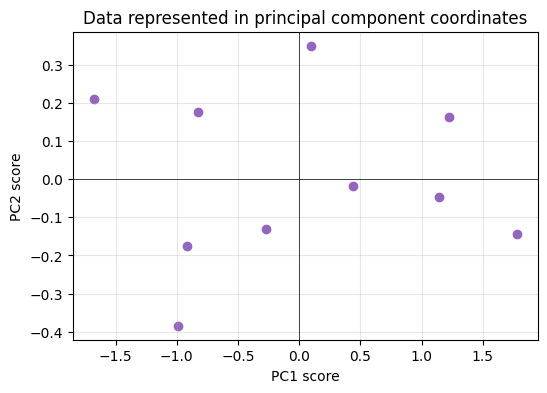

In [26]:
plt.figure(figsize=(6, 4))
plt.scatter(scores[:, 0], scores[:, 1], color="tab:purple")
plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("PC1 score")
plt.ylabel("PC2 score")
plt.title("Data represented in principal component coordinates")
plt.grid(True, alpha=0.3)
plt.show()

The first principal component explains the largest share of variance. Projecting data onto PC1 and PC2 rotates the coordinate system so the strongest variation appears along the first axis.

When the data is projected onto the principal components, it appears uncorrelated, suggesting that the components capture a unique part of the variance in the data.

(NEW) Visualizing PCA space

We overlay the Principal Component grid (red, green) on the feature space. This lets us see the structure of the underlying principal components.

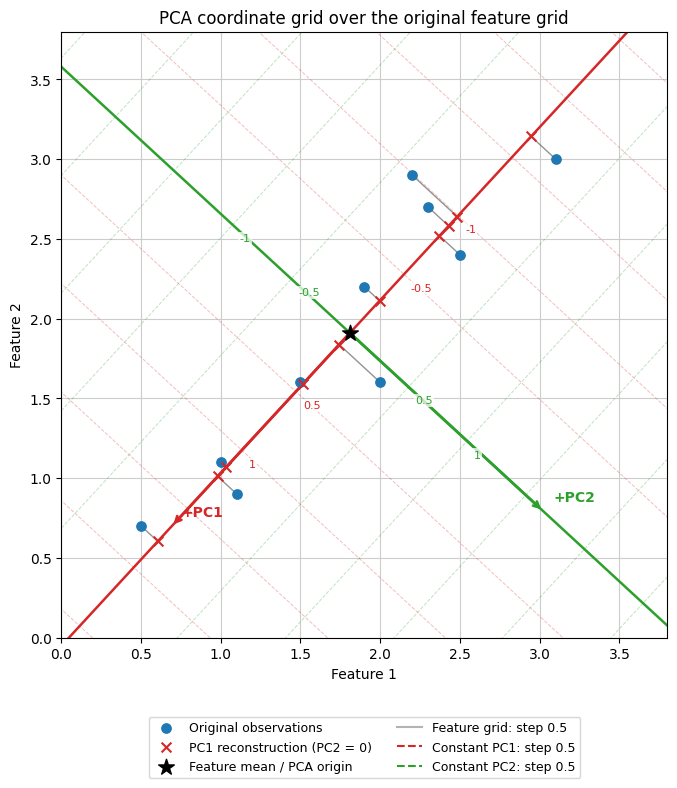

In [27]:
from matplotlib.lines import Line2D

# Map PCA coordinates back into the original feature coordinate system.
# A constant PC2 score gives a line parallel to PC1, and vice versa.
X_pc1 = scores[:, :1] @ Vt_pca[:1, :] + mean
pc1_direction, pc2_direction = Vt_pca
fig, ax = plt.subplots(figsize=(8, 8))
limits = (0.0, 3.8)
ax.set(xlim=limits, ylim=limits, xlabel="Feature 1", ylabel="Feature 2",
       title="PCA coordinate grid over the original feature grid")
ax.set_aspect("equal", adjustable="box")
ax.set_xticks(np.arange(0, 4, 0.5))
ax.set_yticks(np.arange(0, 4, 0.5))
ax.set_axisbelow(True)
ax.grid(color="0.8", linewidth=0.8)

extent = 2 * (limits[1] - limits[0])
t = np.array([-extent, extent])
# Integer multiples of the grid step include zero exactly.
grid_step = 0.5
grid_count = int(np.ceil(extent / grid_step))
grid_scores = np.arange(-grid_count, grid_count + 1) * grid_step
for score in grid_scores:
    along_pc1 = mean + t[:, None] * pc1_direction + score * pc2_direction
    along_pc2 = mean + score * pc1_direction + t[:, None] * pc2_direction
    ax.plot(along_pc1[:, 0], along_pc1[:, 1], color="tab:green",
            linestyle="--", linewidth=0.7, alpha=0.3)
    ax.plot(along_pc2[:, 0], along_pc2[:, 1], color="tab:red",
            linestyle="--", linewidth=0.7, alpha=0.3)

for direction, color, label in [(pc1_direction, "tab:red", "PC1"),
                                 (pc2_direction, "tab:green", "PC2")]:
    axis_line = mean + t[:, None] * direction
    ax.plot(axis_line[:, 0], axis_line[:, 1], color=color, linewidth=1.8)
    tip = mean + 1.65 * direction
    ax.annotate("", xy=tip, xytext=mean,
                arrowprops=dict(arrowstyle="->", color=color, lw=2))
    ax.annotate(f"+{label}", xy=tip, xytext=(7, 7),
                textcoords="offset points", color=color, weight="bold")
    for score in [-1.0, -0.5, 0.5, 1.0]:
        point = mean + score * direction
        ax.annotate(f"{score:g}", xy=point, xytext=(5, -12),
                    textcoords="offset points", fontsize=8, color=color,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1))

ax.scatter(X[:, 0], X[:, 1], color="tab:blue", s=45, zorder=4,
           label="Original observations")
ax.scatter(X_pc1[:, 0], X_pc1[:, 1], color="tab:red", marker="x",
           s=50, zorder=4, label="PC1 reconstruction (PC2 = 0)")
for original, projected in zip(X, X_pc1):
    ax.plot([original[0], projected[0]], [original[1], projected[1]],
            color="0.35", linewidth=1, alpha=0.65)
ax.scatter(*mean, color="black", marker="*", s=140, zorder=5,
           label="Feature mean / PCA origin")
handles, labels = ax.get_legend_handles_labels()
handles += [Line2D([0], [0], color="0.7", label="Feature grid: step 0.5"),
            Line2D([0], [0], color="tab:red", linestyle="--",
                   label="Constant PC1: step 0.5"),
            Line2D([0], [0], color="tab:green", linestyle="--",
                   label="Constant PC2: step 0.5")]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12),
          ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## Reflection and Rubric Checklist

- Code Accuracy and Completeness: I ran the notebook from top to bottom without errors.
- Math Concept Coverage: I demonstrated SVD, low-rank approximation, and PCA.
- Examples Appropriateness: My examples show the concepts clearly and are connected to the math.
- Explanation and Documentation: I explained the purpose and meaning of each code section.
- GitHub and Colab: I saved the notebook directly from Colab to GitHub, and the `Open in Colab` badge is visible and working.
- Format and Clarity: The notebook has a logical flow, readable code, and clear section headings.
- Personalization: I changed or extended at least one example so the notebook reflects my own work.